In [1]:
%pip install -q ultralytics seaborn pyyaml

import json
import random
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import FileLink, display
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
PyTorch: 2.10.0+cu128
CUDA available: True
Device: 0
GPU: Tesla T4


In [2]:
# Change only this path if your Kaggle dataset has a different location.
DATASET_ROOT = Path('/kaggle/input/datasets/qosainshah/data-final/dataset_FYP')
WORK_DIR = Path('/kaggle/working/accident_detection')
RUN_DIR = WORK_DIR / 'runs'
EXPORT_DIR = WORK_DIR / 'export'
WORK_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = {
    'train': DATASET_ROOT / 'train',
    'val': DATASET_ROOT / 'valid',
    'test': DATASET_ROOT / 'test',
}
CLASS_NAMES = ['fire', 'moderate', 'severe']
required = [path / folder for path in SPLITS.values() for folder in ('images', 'labels')]
missing = [str(path) for path in required if not path.is_dir()]
if missing:
    raise FileNotFoundError('Missing dataset folders:\n' + '\n'.join(missing))

for split, path in SPLITS.items():
    print(f'{split}: {path}')

train: /kaggle/input/datasets/qosainshah/data-final/dataset_FYP/train
val: /kaggle/input/datasets/qosainshah/data-final/dataset_FYP/valid
test: /kaggle/input/datasets/qosainshah/data-final/dataset_FYP/test


In [3]:
# Validate labels and image/label pairs before training.
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
audit_rows = []
errors = []

for split, split_path in SPLITS.items():
    images = {path.stem: path for path in (split_path / 'images').iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS}
    labels = {path.stem: path for path in (split_path / 'labels').glob('*.txt')}
    for stem in sorted(set(images) - set(labels)):
        errors.append(f'{split}: missing label for {images[stem].name}')
    for stem in sorted(set(labels) - set(images)):
        errors.append(f'{split}: missing image for {labels[stem].name}')
    for label_path in labels.values():
        for line_number, line in enumerate(label_path.read_text().splitlines(), 1):
            values = line.split()
            if len(values) != 5:
                errors.append(f'{label_path}:{line_number}: expected 5 values')
                continue
            try:
                class_id, x, y, width, height = map(float, values)
            except ValueError:
                errors.append(f'{label_path}:{line_number}: non-numeric label')
                continue
            if class_id != int(class_id) or not 0 <= int(class_id) < len(CLASS_NAMES):
                errors.append(f'{label_path}:{line_number}: invalid class {class_id}')
            if any(value < 0 or value > 1 for value in (x, y, width, height)):
                errors.append(f'{label_path}:{line_number}: coordinates must be 0..1')
    audit_rows.append({'split': split, 'images': len(images), 'labels': len(labels)})

audit = pd.DataFrame(audit_rows)
display(audit)
if errors:
    raise ValueError('Dataset validation failed:\n' + '\n'.join(errors[:50]))
print('Dataset validation passed.')

,split,images,labels
0,train,14400,14400
1,val,1800,1800
2,test,1800,1800


Dataset validation passed.


## Dataset and PyTorch DataLoader

The next cell creates a small PyTorch `Dataset` and `DataLoader` smoke check. It confirms that images and YOLO label files can be batched correctly. Ultralytics uses its optimized detection dataloader internally during training.

In [4]:
from torch.utils.data import DataLoader, Dataset

class AccidentDataset(Dataset):
    def __init__(self, split='train', image_size=640):
        self.image_paths = sorted(
            path for path in (SPLITS[split] / 'images').iterdir()
            if path.suffix.lower() in IMAGE_EXTENSIONS
        )
        self.label_dir = SPLITS[split] / 'labels'
        self.image_size = image_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f'Cannot read image: {image_path}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.image_size, self.image_size))
        labels = []
        label_path = self.label_dir / f'{image_path.stem}.txt'
        for line in label_path.read_text().splitlines():
            if line.strip():
                labels.append(list(map(float, line.split())))
        return torch.from_numpy(image).permute(2, 0, 1), torch.tensor(labels, dtype=torch.float32)


def detection_collate(batch):
    images, labels = zip(*batch)
    return torch.stack(list(images)), list(labels)

loader = DataLoader(
    AccidentDataset('train'),
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=detection_collate,
)
images, labels = next(iter(loader))
print('DataLoader image batch:', tuple(images.shape))
print('DataLoader label batches:', len(labels))
print('DataLoader smoke test passed.')

DataLoader image batch: (4, 3, 640, 640)
DataLoader label batches: 4
DataLoader smoke test passed.


,class,objects
0,fire,11974
1,moderate,6085
2,severe,6143


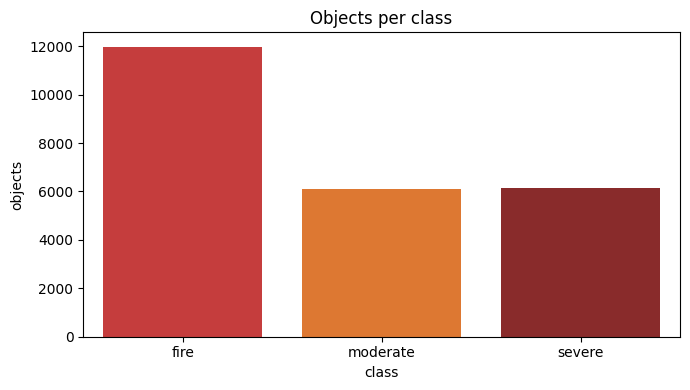

In [5]:
counts = {name: 0 for name in CLASS_NAMES}
for split_path in SPLITS.values():
    for label_path in (split_path / 'labels').glob('*.txt'):
        for line in label_path.read_text().splitlines():
            if line.strip():
                counts[CLASS_NAMES[int(float(line.split()[0]))]] += 1

distribution = pd.DataFrame({'class': list(counts), 'objects': list(counts.values())})
display(distribution)
plt.figure(figsize=(7, 4))
sns.barplot(data=distribution, x='class', y='objects', hue='class', palette=['#dc2626', '#f97316', '#991b1b'], legend=False)
plt.title('Objects per class')
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'class_distribution.png', dpi=150)
plt.show()

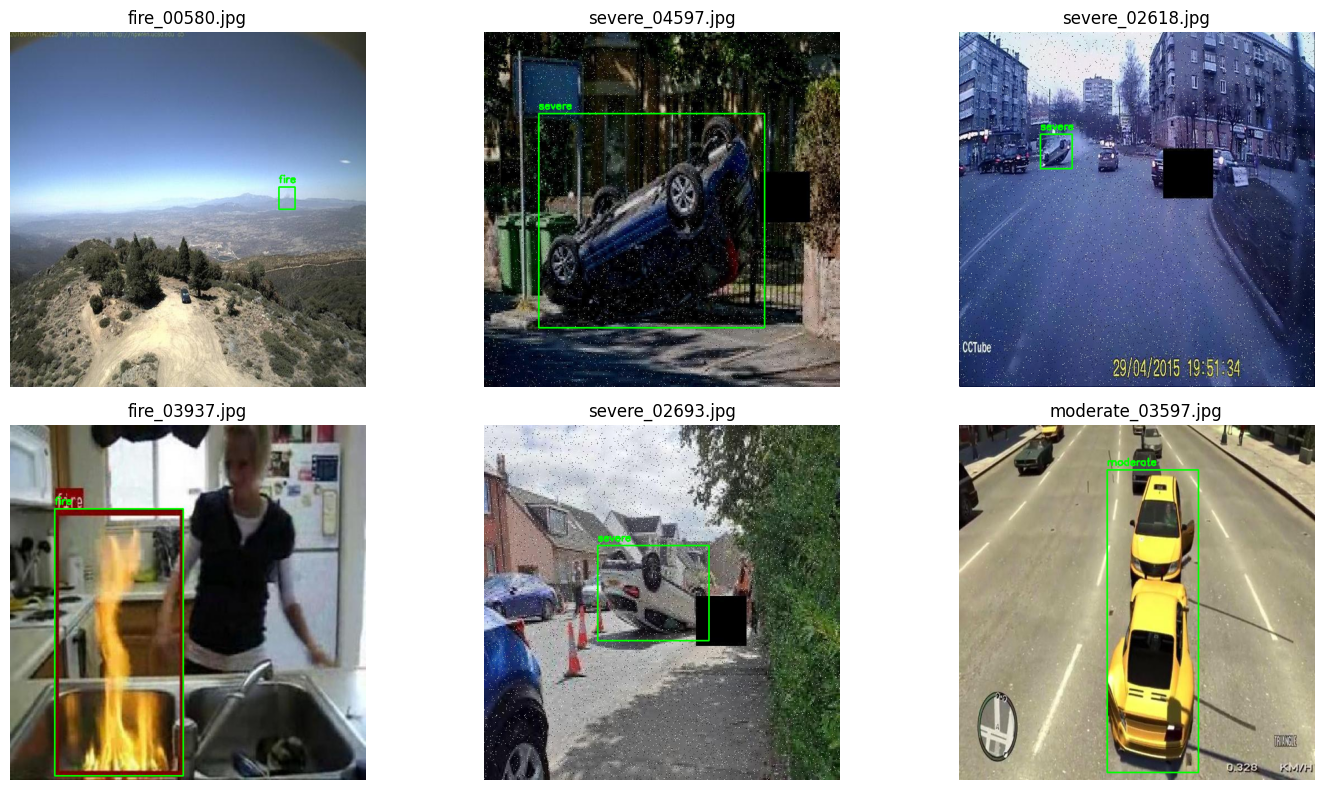

In [6]:
def show_samples(split='train', number=6):
    image_dir = SPLITS[split] / 'images'
    label_dir = SPLITS[split] / 'labels'
    image_files = [path for path in image_dir.iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS]
    selected = random.sample(image_files, min(number, len(image_files)))
    columns = min(3, len(selected))
    rows = (len(selected) + columns - 1) // columns
    plt.figure(figsize=(5 * columns, 4 * rows))
    for index, image_path in enumerate(selected, 1):
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        height, width = image.shape[:2]
        label_path = label_dir / f'{image_path.stem}.txt'
        for line in label_path.read_text().splitlines():
            class_id, x, y, box_width, box_height = map(float, line.split())
            x1 = int((x - box_width / 2) * width)
            y1 = int((y - box_height / 2) * height)
            x2 = int((x + box_width / 2) * width)
            y2 = int((y + box_height / 2) * height)
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, CLASS_NAMES[int(class_id)], (x1, max(y1 - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        plt.subplot(rows, columns, index)
        plt.imshow(image)
        plt.title(image_path.name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples('train')

In [7]:
DATA_YAML = WORK_DIR / 'data.yaml'
yaml_data = {
    'path': str(DATASET_ROOT),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(CLASS_NAMES),
    'names': {index: name for index, name in enumerate(CLASS_NAMES)},
}
DATA_YAML.write_text(yaml.safe_dump(yaml_data, sort_keys=False))
print(DATA_YAML.read_text())

path: /kaggle/input/datasets/qosainshah/data-final/dataset_FYP
train: train/images
val: valid/images
test: test/images
nc: 3
names:
  0: fire
  1: moderate
  2: severe



## Model setup

This project uses an Ultralytics YOLO model backed by PyTorch. The model is created from pretrained weights and fine-tuned for the three accident classes.

In [8]:
MODEL_NAME = 'yolo12n.pt'
model = YOLO(MODEL_NAME)
print('Model:', MODEL_NAME)
print('Model created successfully.')

Model: yolo12n.pt
Model created successfully.


In [10]:
# Kaggle GPU training. Reduce BATCH if CUDA memory is insufficient.
results = model.train(
    data=str(DATA_YAML),
    epochs=40,
    imgsz=640,
    batch=32,
    workers=2,
    device=DEVICE,
    project=str(RUN_DIR),
    name='accident_yolov12',
    optimizer='AdamW',
    patience=15,
    seed=SEED,
    pretrained=True,
    plots=True,
    save=True,
    verbose=True,
)
TRAIN_DIR = Path(results.save_dir)
BEST_PT = TRAIN_DIR / 'weights' / 'best.pt'
print('Training directory:', TRAIN_DIR)
print('Best weights:', BEST_PT)

Ultralytics 8.4.126 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/accident_detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=accident_yolov12

In [11]:
best_model = YOLO(str(BEST_PT))
metrics = best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    batch=16,
    device=DEVICE,
    plots=True,
    verbose=True,
)

summary = {
    'precision': float(metrics.box.mp),
    'recall': float(metrics.box.mr),
    'map50': float(metrics.box.map50),
    'map50_95': float(metrics.box.map),
}
(EXPORT_DIR / 'metrics.json').write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

Ultralytics 8.4.126 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 8.9±6.5 MB/s, size: 53.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/qosainshah/data-final/dataset_FYP/test/labels... 1800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1800/1800 384.4it/s 4.7s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/qosainshah/data-final/dataset_FYP/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 6.3it/s 18.1s0.2s
                   all       1800       2443      0.925      0.868      0.899       0.79
                  fire        600       1223       0.83      0.643      0.7

In [12]:
# Save annotated predictions for visual inspection.
prediction_dir = EXPORT_DIR / 'sample_predictions'
prediction_dir.mkdir(parents=True, exist_ok=True)
test_images = [path for path in (SPLITS['test'] / 'images').iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS]
selected = random.sample(test_images, min(6, len(test_images)))
for image_path in selected:
    prediction = best_model.predict(source=str(image_path), conf=0.45, imgsz=640, device=DEVICE, verbose=False)[0]
    annotated = prediction.plot()
    cv2.imwrite(str(prediction_dir / image_path.name), annotated)

print('Saved predictions:', len(list(prediction_dir.iterdir())))

Saved predictions: 6


In [13]:
# Build a single download bundle for the local FastAPI project.
export_pt = EXPORT_DIR / 'best.pt'
shutil.copy2(BEST_PT, export_pt)
shutil.copy2(DATA_YAML, EXPORT_DIR / 'data.yaml')
shutil.copytree(TRAIN_DIR, EXPORT_DIR / 'training_run', dirs_exist_ok=True)

readme = '''Accident detection model bundle

Classes: 0=fire, 1=moderate, 2=severe
Model file: best.pt

Install the model locally with:
cp best.pt backend/ml_model/best.pt

The backend must use the same class order.
'''
(EXPORT_DIR / 'MODEL_README.txt').write_text(readme)

BUNDLE_ZIP = WORK_DIR / 'accident_model_bundle.zip'
if BUNDLE_ZIP.exists():
    BUNDLE_ZIP.unlink()
shutil.make_archive(str(BUNDLE_ZIP.with_suffix('')), 'zip', root_dir=EXPORT_DIR)
print('Bundle:', BUNDLE_ZIP)
display(FileLink(str(BUNDLE_ZIP)))

Bundle: /kaggle/working/accident_detection/accident_model_bundle.zip


/kaggle/working/accident_detection/accident_model_bundle.zip

In [14]:
# Final artifact checklist.
assert BEST_PT.exists(), BEST_PT
assert (EXPORT_DIR / 'data.yaml').exists()
assert (EXPORT_DIR / 'metrics.json').exists()
assert BUNDLE_ZIP.exists() and BUNDLE_ZIP.stat().st_size > 0
print('READY TO DOWNLOAD')
print('Download:', BUNDLE_ZIP)
print('Copy best.pt to: backend/ml_model/best.pt')

READY TO DOWNLOAD
Download: /kaggle/working/accident_detection/accident_model_bundle.zip
Copy best.pt to: backend/ml_model/best.pt
